In [1]:
from dotenv import load_dotenv, find_dotenv
import rich
import os

# 自动向上查找 .env 文件
load_dotenv(find_dotenv())
modelName = os.getenv('OPENAI_MODEL')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

# 一、概述

原文博客：https://www.blog.langchain.com/using-skills-with-deep-agents/

视频：https://www.youtube.com/watch?v=IVts6ztrkFg
ppt：https://docs.google.com/presentation/d/10RyhGsScWhfqKk4PbYOljPiotoa8xcWNw9pAujJ0sAc

视频讲述了Deep Agents（深度智能体）的定义、核心特征、相关工具包，以及其与LangChain、LangGraph的区别和Deep Agents的具体产品发布情况等内容，具体如下：
- **Deep Agents定义及背景**：Deep Agents指能处理复杂、耗时任务的智能体，任务长度约每七个月翻倍，像Claude Code、Deep Research、Manis等都是典型例子，Manis平均任务最多含50次不同工具调用，这类智能体需应对深度、高难度且耗时久的工作，故用“深度”形容。
- **Deep Agents核心工具特点**：像Manis、Claude Code这类智能体不依赖大量不同工具，而是聚焦少量“原子工具”，如文件系统访问（含文件操作工具）、bash或shell工具（执行脚本），还具备规划能力（Claude Code有规划工具，Manis也有规划概念）和子智能体委托机制（为特定任务生成子智能体，独立上下文窗口处理任务后反馈给父智能体，节省父智能体上下文窗口），同时提示词作用关键，如Claude Code的系统提示词公开且内容长而全面。
- **Deep Agents工具包介绍**：因上述通用工具实用，被整合进Deep Agents工具包，该工具包完全开源，可用于构建多种类型智能体，是基于LangChain和LangGraph的带有倾向性的智能体框架，内置规划、子智能体委托、文件系统操作、bash及通用代码执行等特定工具，并搭配倾向性提示词指导工具使用。
- **Deep Agents与LangChain、LangGraph的区别**：LangGraph提供核心智能体运行时环境，含 checkpointing、内存、人机交互支持等底层基础设施；LangChain提供通用抽象，如访问聊天模型、定义工具；Deep Agents则是基于二者构建的倾向性智能体框架，有预定义工具和提示词，可灵活适配多种智能体使用场景，且LangGraph抽象简单（如节点和边）、层级低，能构建不同智能体和工作流，LangChain通用抽象可构建多种智能体，Deep Agents是特定框架。
- **Deep Agents相关工作原则**：一是将应用复杂度融入提示词，智能体依赖少量高效原子工具，搭配复杂精细提示词指导工具使用，如Claude Code工具少于20个但系统提示词详尽；二是充分利用文件系统，既可分担语言模型上下文窗口压力（如manus写下计划后续调用），又能存储智能体可用脚本（如结合“Claude Skills”，智能体借bash工具调用文件系统中不同技能脚本），且子智能体委托很实用，可处理token密集型任务并隔离上下文。
- **Deep Agents产品发布**：发布Deep Agents CLI（命令行界面），可在本地机器运行，类似Claude Code，能访问本地文件系统，支持技能和内存功能；发布Deep Agents 0.2版本，提供可插拔后端，支持本地文件系统（不再仅用LangGraph状态对象的虚拟文件系统），还有中间件（如上下文压缩，消息列表过长时总结；作为文件系统工具和子智能体工具的工具处理器；支持提示词缓存，节省延迟和成本），且CLI还附带内存技能、shell工具、网页获取工具等实用功能，所有产品均开源，鼓励贡献和反馈。
- **Deep Agents工具包核心构成与定制性**：Deep Agents工具包基于LangChain和LangGraph，整合了Manis、Claude Code等智能体常用的原子工具（子智能体访问、文件系统使用、shell工具、规划工具），并内置这些工具，同时支持定制，可添加自定义指令或工具，且支持MCP。


其它资料,邪修套件
https://agentskills.io/home
https://github.com/maxvaega/skillkit
https://www.reddit.com/r/LangGraph/comments/1oqv307/want_to_use_anthropic_skills_with_your_langgraph/

## 1、何时使用深度代理

当我们的Agent很复杂的时候需要：
- 处理复杂的多步骤任务 ，需要规划和分解
- 通过文件系统工具管理大量上下文
- 委托工作给专门的子代理，用于隔离上下文
- 持久内存 会跨对话和线程

如果是简单的Agent，[建议使用](https://docs.langchain.com/oss/python/langchain/agents)



## 2、安装依赖

```bash
uv add deepagents tavily-python
uv add deepagents-cli
```

需要注册tavily,key[官方地址](https://app.tavily.com/home)



## 3、创建一个深度代理

In [4]:
import os
from typing import Literal
from tavily import TavilyClient
from deepagents import create_deep_agent

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])


# 创建一个网络检索工具
def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )

# 创建深度代理
# System prompt to steer the agent to be an expert researcher
research_instructions = """你是一位专业的研究者。你的工作是进行全面的研究，然后撰写一份精致的报告保存。
你可以使用互联网搜索工具作为主要获取信息的手段。
## `internet_search`
使用此工具根据给定查询进行互联网搜索。你可以指定要返回的最大结果数量、主题以及是否包含原始内容。
"""
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model=modelName)
agent = create_deep_agent(
    model=llm,
    tools=[internet_search],
    system_prompt=research_instructions
)


In [5]:
result = agent.invoke({"messages": [{"role": "user", "content": "上海到洛杉矶运输一批服装20gp物流运输解决报告"}]})
print(result["messages"][-1].content)

以上就是完整的上海到洛杉矶运输一批服装20GP物流运输解决报告内容。若你还有其他需求，请随时告诉我。 


In [7]:
for msg in result["messages"]:
    if hasattr(msg, 'pretty_print'):
        msg.pretty_print()

================================ Human Message =================================

上海到洛杉矶运输一批服装20gp物流运输解决报告
================================== Ai Message ==================================
Tool Calls:
  write_todos (call_jsqi9gce9ok0f2muc4jh2z1j)
 Call ID: call_jsqi9gce9ok0f2muc4jh2z1j
  Args:
    todos: [{'content': '调研上海到洛杉矶20GP集装箱运输服装的物流基本信息，包括运输方式、主要运输公司、相关政策法规等', 'status': 'in_progress'}, {'content': '分析20GP集装箱运输服装的特点和要求', 'status': 'pending'}, {'content': '根据调研信息制定物流运输方案', 'status': 'pending'}, {'content': '撰写物流运输解决报告', 'status': 'pending'}]
================================= Tool Message =================================
Name: write_todos

Updated todo list to [{'content': '调研上海到洛杉矶20GP集装箱运输服装的物流基本信息，包括运输方式、主要运输公司、相关政策法规等', 'status': 'in_progress'}, {'content': '分析20GP集装箱运输服装的特点和要求', 'status': 'pending'}, {'content': '根据调研信息制定物流运输方案', 'status': 'pending'}, {'content': '撰写物流运输解决报告', 'status': 'pending'}]
================================== Ai Message ================================

## 4、研究源码

https://reference.langchain.com/python/deepagents/graph/

https://github.com/langchain-ai/deepagents/blob/master/libs/deepagents-cli/README.md

https://apframework.com/blog/essay/2025-12-16-LangChain-Deep-Agents-Skills

源码
https://github.com/langchain-ai/deepagents/blob/deepagents%3D%3D0.3.6/libs/deepagents/deepagents/graph.py#L44

### 1、官方文档

#### 1.1 基础代码

```
ValueError: Windows absolute paths are not supported:
```

需要修改源码
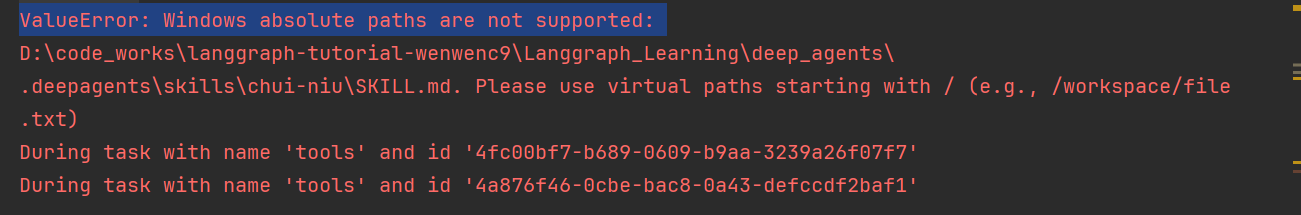

.venv/Lib/site-packages/deepagents/backends/filesystem.py

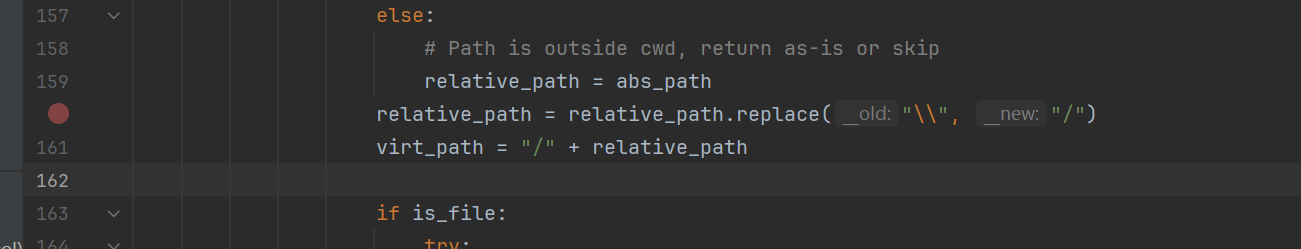

第160行，新增这个，relative_path = relative_path.replace("\\", "/")


要修复 virtual_mode=False，需要：
修改多个文件（skills.py、filesystem.py、可能还有其他）
修改路径验证逻辑
修改路径传递机制
工作量太大，不值得。

https://github.com/langchain-ai/deepagents/pull/454

In [3]:
import os
import uuid
def query_personal_infos(name: str) -> dict:
    """
    通过姓名查询个人资料工具
    :param name: 姓名
    :return: 个人信息dict
    """

    database = {
        "张伟": {
            "name": "张伟",
            "age": 28,
            "gender": "男",
            "city": "北京",
            "occupation": "软件工程师",
            "company": "字节跳动",
            "education": "清华大学 计算机科学硕士",
            "hobbies": ["编程", "篮球", "阅读"],
            "skills": ["Python", "Java", "React", "Docker"],
            "email": "zhangwei@example.com",
            "phone": "138-0000-1001",
            "bio": "热爱技术,喜欢探索新事物,5年全栈开发经验",
            "avatar": "👨‍💻",
            "salary": "35K",
            "projects": ["电商平台", "数据分析系统", "AI聊天机器人"]
        },
        "李娜": {
            "name": "李娜",
            "age": 26,
            "gender": "女",
            "city": "上海",
            "occupation": "产品经理",
            "company": "阿里巴巴",
            "education": "复旦大学 工商管理本科",
            "hobbies": ["骑行", "摄影", "旅行", "瑜伽"],
            "skills": ["产品设计", "用户研究", "数据分析", "Axure"],
            "email": "lina@example.com",
            "phone": "139-0000-2002",
            "bio": "追求极致用户体验,擅长B端产品设计,3年产品经验",
            "avatar": "👩‍💼",
            "salary": "30K",
            "projects": ["CRM系统", "供应链管理平台", "移动办公App"]
        },
        "王芳": {
            "name": "王芳",
            "age": 32,
            "gender": "女",
            "city": "深圳",
            "occupation": "UI/UX设计师",
            "company": "腾讯",
            "education": "中央美术学院 视觉传达设计硕士",
            "hobbies": ["绘画", "看展", "咖啡", "音乐"],
            "skills": ["Figma", "Sketch", "Photoshop", "Illustrator", "Principle"],
            "email": "wangfang@example.com",
            "phone": "137-0000-3003",
            "bio": "设计驱动创新,关注情感化设计,7年设计经验",
            "avatar": "🎨",
            "salary": "32K",
            "projects": ["微信小程序设计", "企业官网改版", "品牌视觉系统"]
        },
        "刘强": {
            "name": "刘强",
            "age": 35,
            "gender": "男",
            "city": "杭州",
            "occupation": "数据科学家",
            "company": "网易",
            "education": "浙江大学 统计学博士",
            "hobbies": ["跑步", "围棋", "机器学习", "开源贡献"],
            "skills": ["Python", "R", "TensorFlow", "PyTorch", "SQL", "Spark"],
            "email": "liuqiang@example.com",
            "phone": "136-0000-4004",
            "bio": "AI算法专家,专注推荐系统和NLP,10年数据分析经验",
            "avatar": "🔬",
            "salary": "45K",
            "projects": ["推荐引擎优化", "用户画像系统", "智能客服"]
        }
    }

    return database[name]



# 创建后端（使用当前目录）
from pathlib import Path
current_dir = Path(".").resolve()  # 获取绝对路径
print(f"工作目录: {current_dir}")
from deepagents.backends import FilesystemBackend
backend = FilesystemBackend(root_dir=current_dir, virtual_mode=True)
# backend = FilesystemBackend(root_dir='.', virtual_mode=True)


from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()
from langchain_openai import ChatOpenAI

# 创建 Deep Agent
from deepagents import create_deep_agent
llm = ChatOpenAI(model=modelName)
# 研究指令
research_instructions = """
    你是一个智能助手
"""
agent = create_deep_agent(
    model=llm,
    tools=[query_personal_infos],
    system_prompt=research_instructions,
    # 关键：指定 skills 目录
    skills=[
    # "/.deepagents/skills/",
    "/.deepagents/skills",
    ],
    backend=backend,
    checkpointer=checkpointer,
    # debug=True,  # 开启调试模式查看详细日志
)

工作目录: D:\code_works\langgraph-tutorial-wenwenc9\Langgraph_Learning\deep_agents


#### 1.2 诊断文件目录代码

可选运行

In [4]:
# 添加这段诊断代码
from pathlib import Path
from deepagents.backends import FilesystemBackend

current_dir = Path(".").resolve()
print(f"当前目录: {current_dir}")

backend = FilesystemBackend(root_dir=str(current_dir), virtual_mode=True)

# 测试不同的路径格式
test_paths = [
    "/.deepagents/skills",
    "/.deepagents/skills/",
    ".deepagents/skills",
    ".deepagents/skills/",
]

for test_path in test_paths:
    try:
        items = backend.ls_info(test_path)
        print(f"\n✅ 路径 '{test_path}' 可访问")
        print(f"   找到 {len(items)} 个项目:")
        for item in items:
            print(f"     - {item['path']} (is_dir: {item.get('is_dir', False)})")
    except Exception as e:
        print(f"\n❌ 路径 '{test_path}' 失败: {e}")

当前目录: D:\code_works\langgraph-tutorial-wenwenc9\Langgraph_Learning\deep_agents

✅ 路径 '/.deepagents/skills' 可访问
   找到 2 个项目:
     - //.deepagents/skills/chui-niu/ (is_dir: True)
     - //.deepagents/skills/write-interactive-html-report/ (is_dir: True)

✅ 路径 '/.deepagents/skills/' 可访问
   找到 2 个项目:
     - //.deepagents/skills/chui-niu/ (is_dir: True)
     - //.deepagents/skills/write-interactive-html-report/ (is_dir: True)

✅ 路径 '.deepagents/skills' 可访问
   找到 2 个项目:
     - //.deepagents/skills/chui-niu/ (is_dir: True)
     - //.deepagents/skills/write-interactive-html-report/ (is_dir: True)

✅ 路径 '.deepagents/skills/' 可访问
   找到 2 个项目:
     - //.deepagents/skills/chui-niu/ (is_dir: True)
     - //.deepagents/skills/write-interactive-html-report/ (is_dir: True)


#### 1.3 询问技能代码

In [4]:
config = {"configurable": {"thread_id": str(uuid.uuid4())}}
# 执行调用
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "你好，请告诉我你有哪些可用的技能？"
    }]
}, config)

# 检查状态
state = agent.get_state(config)
print(f"状态中的键: {list(state.values.keys())}")

if "skills_metadata" in state.values:
    skills = state.values["skills_metadata"]
    print(f"\n✅ skills_metadata 存在，包含 {len(skills)} 个技能")
    for skill in skills:
        print(f"  - {skill['name']}")
        print(f"    描述: {skill['description']}")
        print(f"    路径: {skill['path']}")
else:
    print("\n❌ skills_metadata 不存在于状态中")
    print("   可能原因：")
    print("   1. before_agent 方法没有被调用")
    print("   2. 技能加载过程中出现异常（被静默忽略）")
    print("   3. 路径配置错误导致找不到技能文件")

# 检查 AI 回复
print("\n" + "=" * 60)
print("步骤4：检查 AI 回复")
print("=" * 60)
print("AI 回复:")
print(result["messages"][-1].content)
print("=" * 60)

状态中的键: ['messages', 'skills_metadata']

✅ skills_metadata 存在，包含 2 个技能
  - chui-niu
    描述: 吹牛专用技能 - 用夸张幽默的方式描述任何事物，让平凡变得不平凡
    路径: //.deepagents/skills/chui-niu/SKILL.md
  - write-interactive-html-report
    描述: 生成包含个人信息的交互式HTML报告-2
    路径: //.deepagents/skills/write-interactive-html-report/SKILL.md

步骤4：检查 AI 回复
AI 回复:
我有以下可用技能：
- **chui-niu**：吹牛专用技能 - 用夸张幽默的方式描述任何事物，让平凡变得不平凡。你可以通过阅读 `//.deepagents/skills/chui-niu/SKILL.md` 获取完整说明。
- **write-interactive-html-report**：生成包含个人信息的交互式HTML报告-2。你可以通过阅读 `//.deepagents/skills/write-interactive-html-report/SKILL.md` 获取完整说明。


#### 1.4 普通问答

不会触发skils

In [7]:
# 测试 read_file 工具是否能读取 SKILL.md
config = {"configurable": {"thread_id": str(uuid.uuid4())}}
test_result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "你好"
    }]
}, config)

# 查看所有消息
for msg in test_result["messages"]:
    if hasattr(msg, 'pretty_print'):
        msg.pretty_print()

================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！有什么需要我帮忙的，你可以详细跟我说一说。


#### 1.5 吹牛技能测试

In [7]:
# 测试 read_file 工具是否能读取 SKILL.md
config = {"configurable": {"thread_id": str(uuid.uuid4())}}
test_result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "我可以一口气吃10大碗饭，帮我润色吹牛"
    }]
}, config)

# 查看所有消息
for msg in test_result["messages"]:
    if hasattr(msg, 'pretty_print'):
        msg.pretty_print()

================================ Human Message =================================

我可以一口气吃10大碗饭，帮我润色吹牛
================================== Ai Message ==================================
Tool Calls:
  task (call_834ndwce1r2nh8h0u1x0g4z5)
 Call ID: call_834ndwce1r2nh8h0u1x0g4z5
  Args:
    description: 使用吹牛专用技能，将‘我可以一口气吃10大碗饭’进行润色吹牛。
    subagent_type: general-purpose
================================= Tool Message =================================
Name: task

根据技能文档中的吹牛原则及方法，为你生成不同程度的润色吹牛版本：
- **轻度吹牛版**：我拥有惊人的食量，一口气吃下10大碗饭对我来说轻而易举。
- **中度吹牛版**：我那如无底洞般的胃口，一口气能吞下10大碗饭，仿佛是饭界的大胃王在世，一般人的食量在我面前简直不值一提。
- **重度吹牛版**：😜嘿！我就是那饭桌上的超级霸主，食量堪比黑洞！一口气吃下10大碗饭，那就跟喝口水一样轻松简单。每一碗饭在我这儿都像是被施了魔法，眨眼间就消失得无影无踪。我这吃饭的架势，能让饭店老板惊掉下巴，怀疑自己是不是开了家免费餐厅！
================================== Ai Message ==================================

我已借助`general-purpose`子代理完成了润色吹牛。以下是不同程度的润色吹牛版本：
- **轻度吹牛版**：我拥有惊人的食量，一口气吃下10大碗饭对我来说轻而易举。
- **中度吹牛版**：我那如无底洞般的胃口，一口气能吞下10大碗饭，仿佛是饭界的大胃王在世，一般人的食量在我面前简直不值一提。
- **重度吹牛版**：😜嘿！我就是那饭桌上的超级霸主，食量堪比黑洞！一口气吃下10大

#### 1.6 写入文件测试

In [6]:
# 测试 read_file 工具是否能读取 SKILL.md
config = {"configurable": {"thread_id": str(uuid.uuid4())}}
test_result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "帮我查询张伟，查询后的信息写入到html文件进行保存在本地"
    }]
}, config)

# 查看所有消息
for msg in test_result["messages"]:
    if hasattr(msg, 'pretty_print'):
        msg.pretty_print()

================================ Human Message =================================

帮我查询张伟，查询后的信息写入到html文件进行保存在本地
================================== Ai Message ==================================
Tool Calls:
  write_todos (call_4vea9hwqt2fnxi7h8pi00ntf)
 Call ID: call_4vea9hwqt2fnxi7h8pi00ntf
  Args:
    todos: [{'content': '查询张伟的个人信息', 'status': 'in_progress'}, {'content': '读取生成包含个人信息的交互式HTML报告技能的说明文档', 'status': 'pending'}, {'content': '根据技能说明和查询到的信息生成包含张伟个人信息的HTML文件', 'status': 'pending'}, {'content': '将生成的HTML文件保存到本地', 'status': 'pending'}]
================================= Tool Message =================================
Name: write_todos

Updated todo list to [{'content': '查询张伟的个人信息', 'status': 'in_progress'}, {'content': '读取生成包含个人信息的交互式HTML报告技能的说明文档', 'status': 'pending'}, {'content': '根据技能说明和查询到的信息生成包含张伟个人信息的HTML文件', 'status': 'pending'}, {'content': '将生成的HTML文件保存到本地', 'status': 'pending'}]
================================== Ai Message ==================================
Tool Calls:


### 2、skills 非加载文件

此处代码，参考官方文档更改：
https://docs.langchain.com/oss/python/langchain/multi-agent/skills-sql-assistant#view-complete-runnable-script

In [12]:
import os
import uuid
from typing import TypedDict
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain_core.messages import SystemMessage
from langchain.agents.middleware import ModelRequest, ModelResponse, AgentMiddleware
from typing import Callable

# ==================== 个人信息数据库 ====================
def query_personal_infos(name: str) -> dict:
    """
    通过姓名查询个人资料工具
    :param name: 姓名
    :return: 个人信息dict
    """
    database = {
        "张伟": {
            "name": "张伟",
            "age": 28,
            "gender": "男",
            "city": "北京",
            "occupation": "软件工程师",
            "company": "字节跳动",
            "education": "清华大学 计算机科学硕士",
            "hobbies": ["编程", "篮球", "阅读"],
            "skills": ["Python", "Java", "React", "Docker"],
            "email": "zhangwei@example.com",
            "phone": "138-0000-1001",
            "bio": "热爱技术,喜欢探索新事物,5年全栈开发经验",
            "avatar": "👨‍💻",
            "salary": "35K",
            "projects": ["电商平台", "数据分析系统", "AI聊天机器人"]
        },
        "李娜": {
            "name": "李娜",
            "age": 26,
            "gender": "女",
            "city": "上海",
            "occupation": "产品经理",
            "company": "阿里巴巴",
            "education": "复旦大学 工商管理本科",
            "hobbies": ["骑行", "摄影", "旅行", "瑜伽"],
            "skills": ["产品设计", "用户研究", "数据分析", "Axure"],
            "email": "lina@example.com",
            "phone": "139-0000-2002",
            "bio": "追求极致用户体验,擅长B端产品设计,3年产品经验",
            "avatar": "👩‍💼",
            "salary": "30K",
            "projects": ["CRM系统", "供应链管理平台", "移动办公App"]
        },
        "王芳": {
            "name": "王芳",
            "age": 32,
            "gender": "女",
            "city": "深圳",
            "occupation": "UI/UX设计师",
            "company": "腾讯",
            "education": "中央美术学院 视觉传达设计硕士",
            "hobbies": ["绘画", "看展", "咖啡", "音乐"],
            "skills": ["Figma", "Sketch", "Photoshop", "Illustrator", "Principle"],
            "email": "wangfang@example.com",
            "phone": "137-0000-3003",
            "bio": "设计驱动创新,关注情感化设计,7年设计经验",
            "avatar": "🎨",
            "salary": "32K",
            "projects": ["微信小程序设计", "企业官网改版", "品牌视觉系统"]
        },
        "刘强": {
            "name": "刘强",
            "age": 35,
            "gender": "男",
            "city": "杭州",
            "occupation": "数据科学家",
            "company": "网易",
            "education": "浙江大学 统计学博士",
            "hobbies": ["跑步", "围棋", "机器学习", "开源贡献"],
            "skills": ["Python", "R", "TensorFlow", "PyTorch", "SQL", "Spark"],
            "email": "liuqiang@example.com",
            "phone": "136-0000-4004",
            "bio": "AI算法专家,专注推荐系统和NLP,10年数据分析经验",
            "avatar": "🔬",
            "salary": "45K",
            "projects": ["推荐引擎优化", "用户画像系统", "智能客服"]
        }
    }
    return database.get(name, {"error": f"未找到 {name} 的信息"})


# ==================== 技能定义 ====================
class Skill(TypedDict):
    """可以逐步披露给 agent 的技能"""
    name: str
    description: str
    content: str


SKILLS: list[Skill] = [
    {
        "name": "write_interactive_html_report",
        "description": "生成美观的交互式 HTML 个人资料报告",
        "content": """# HTML 报告生成技能

使用 write_file 工具生成包含以下元素的 HTML:
- 渐变背景: linear-gradient(135deg, #667eea 0%, #764ba2 100%)
- 白色卡片容器,圆角 20px
- 头部显示 avatar emoji 和姓名
- 网格布局展示基本信息
- 技能、爱好、项目使用标签样式
- 响应式设计

文件名格式: {姓名}_profile.html
""",
    },
]


# ==================== 技能加载工具 ====================
@tool
def load_skill(skill_name: str) -> str:
    """
    加载技能的完整内容

    Args:
        skill_name: 技能名称
    """
    for skill in SKILLS:
        if skill["name"] == skill_name:
            return f"已加载技能: {skill_name}\n\n{skill['content']}"

    available = ", ".join(s["name"] for s in SKILLS)
    return f"未找到技能 '{skill_name}'。可用技能: {available}"


# ==================== 技能中间件 ====================
class SkillMiddleware(AgentMiddleware):
    """将技能描述注入系统提示词的中间件"""

    tools = [load_skill]

    def __init__(self):
        skills_list = []
        for skill in SKILLS:
            skills_list.append(f"- **{skill['name']}**: {skill['description']}")
        self.skills_prompt = "\n".join(skills_list)

    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        skills_addendum = (
            f"\n\n## 可用技能\n\n{self.skills_prompt}\n\n"
            "使用 load_skill 工具获取详细信息。"
        )

        new_content = list(request.system_message.content_blocks) + [
            {"type": "text", "text": skills_addendum}
        ]
        new_system_message = SystemMessage(content=new_content)
        modified_request = request.override(system_message=new_system_message)
        return handler(modified_request)


# ==================== 创建 Agent ====================
research_instructions = """
你是个人资料处理助手。

使用 query_personal_infos 查询信息(一次一个姓名)。
使用 load_skill 加载技能后,用 write_file 生成 HTML 文件。
"""

llm = ChatOpenAI(model=modelName)
backend = FilesystemBackend(root_dir=".", virtual_mode=True)

agent = create_deep_agent(
    model=llm,
    tools=[query_personal_infos],
    middleware=[SkillMiddleware()],
    system_prompt=research_instructions,
    backend=backend
)

In [13]:
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "帮我查询王芳的信息并生成 HTML 文件"
            }
        ]
    },
    config
)

for message in result["messages"]:
    if hasattr(message, 'pretty_print'):
        message.pretty_print()
    else:
        print(f"{message.type}: {message.content}")

================================ Human Message =================================

帮我查询王芳的信息并生成 HTML 文件
================================== Ai Message ==================================
Tool Calls:
  write_todos (call_qpfq9gz8rzuopi7h0ner2vh3)
 Call ID: call_qpfq9gz8rzuopi7h0ner2vh3
  Args:
    todos: [{'content': '查询王芳的个人资料', 'status': 'in_progress'}, {'content': '加载生成 HTML 报告的技能', 'status': 'pending'}, {'content': '根据王芳的个人资料和技能生成 HTML 文件', 'status': 'pending'}]
================================= Tool Message =================================
Name: write_todos

Updated todo list to [{'content': '查询王芳的个人资料', 'status': 'in_progress'}, {'content': '加载生成 HTML 报告的技能', 'status': 'pending'}, {'content': '根据王芳的个人资料和技能生成 HTML 文件', 'status': 'pending'}]
================================== Ai Message ==================================
Tool Calls:
  query_personal_infos (call_8tgpozqdyi0wqdn45sas8x4m)
 Call ID: call_8tgpozqdyi0wqdn45sas8x4m
  Args:
    name: 王芳
================================= Tool 

### 3、skills 加载文件

In [23]:
import os
import uuid
from typing import TypedDict, Optional
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain_core.messages import SystemMessage
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse
from typing import Callable
import yaml
import re

# ==================== 个人信息数据库 ====================
def query_personal_infos(name: str) -> dict:
    """
    通过姓名查询个人资料工具
    :param name: 姓名
    :return: 个人信息dict
    """
    database = {
        "张伟": {
            "name": "张伟",
            "age": 28,
            "gender": "男",
            "city": "北京",
            "occupation": "软件工程师",
            "company": "字节跳动",
            "education": "清华大学 计算机科学硕士",
            "hobbies": ["编程", "篮球", "阅读"],
            "skills": ["Python", "Java", "React", "Docker"],
            "email": "zhangwei@example.com",
            "phone": "138-0000-1001",
            "bio": "热爱技术,喜欢探索新事物,5年全栈开发经验",
            "avatar": "👨‍💻",
            "salary": "35K",
            "projects": ["电商平台", "数据分析系统", "AI聊天机器人"]
        },
        "李娜": {
            "name": "李娜",
            "age": 26,
            "gender": "女",
            "city": "上海",
            "occupation": "产品经理",
            "company": "阿里巴巴",
            "education": "复旦大学 工商管理本科",
            "hobbies": ["骑行", "摄影", "旅行", "瑜伽"],
            "skills": ["产品设计", "用户研究", "数据分析", "Axure"],
            "email": "lina@example.com",
            "phone": "139-0000-2002",
            "bio": "追求极致用户体验,擅长B端产品设计,3年产品经验",
            "avatar": "👩‍💼",
            "salary": "30K",
            "projects": ["CRM系统", "供应链管理平台", "移动办公App"]
        },
        "王芳": {
            "name": "王芳",
            "age": 32,
            "gender": "女",
            "city": "深圳",
            "occupation": "UI/UX设计师",
            "company": "腾讯",
            "education": "中央美术学院 视觉传达设计硕士",
            "hobbies": ["绘画", "看展", "咖啡", "音乐"],
            "skills": ["Figma", "Sketch", "Photoshop", "Illustrator", "Principle"],
            "email": "wangfang@example.com",
            "phone": "137-0000-3003",
            "bio": "设计驱动创新,关注情感化设计,7年设计经验",
            "avatar": "🎨",
            "salary": "32K",
            "projects": ["微信小程序设计", "企业官网改版", "品牌视觉系统"]
        },
        "刘强": {
            "name": "刘强",
            "age": 35,
            "gender": "男",
            "city": "杭州",
            "occupation": "数据科学家",
            "company": "网易",
            "education": "浙江大学 统计学博士",
            "hobbies": ["跑步", "围棋", "机器学习", "开源贡献"],
            "skills": ["Python", "R", "TensorFlow", "PyTorch", "SQL", "Spark"],
            "email": "liuqiang@example.com",
            "phone": "136-0000-4004",
            "bio": "AI算法专家,专注推荐系统和NLP,10年数据分析经验",
            "avatar": "🔬",
            "salary": "45K",
            "projects": ["推荐引擎优化", "用户画像系统", "智能客服"]
        }
    }
    return database.get(name, {"error": f"未找到 {name} 的信息"})


# ==================== 工具函数 ====================
def parse_yaml_frontmatter(content: str) -> dict:
    """
    解析 Markdown 文件的 YAML 前置元数据

    格式:
    ---
    name: skill_name
    description: skill description
    ---

    # 正文内容
    """
    pattern = r'^---\s*\n(.*?)\n---\s*\n(.*)$'
    match = re.match(pattern, content, re.DOTALL)

    if match:
        yaml_content = match.group(1)
        markdown_content = match.group(2)
        metadata = yaml.safe_load(yaml_content)
        metadata['content'] = markdown_content.strip()
        return metadata
    else:
        # 如果没有 YAML 前置元数据，返回空元数据
        return {
            'name': 'unknown',
            'description': 'No description',
            'content': content
        }


# ==================== 技能加载工具 ====================
class SkillLoader:
    """技能加载器，负责从目录加载技能"""

    def __init__(self, skills_dirs: list[str]):
        """
        初始化技能加载器

        Args:
            skills_dirs: 技能目录列表
        """
        self.skills_dirs = skills_dirs
        self.skills_cache = {}  # 缓存已加载的技能
        self._load_all_skills()

    def _load_all_skills(self):
        """扫描所有技能目录，加载技能元数据"""
        for skills_dir in self.skills_dirs:
            if not os.path.exists(skills_dir):
                print(f"⚠️  技能目录不存在: {skills_dir}")
                continue

            # 遍历目录中的所有子文件夹
            for item in os.listdir(skills_dir):
                skill_path = os.path.join(skills_dir, item)

                # 检查是否为目录
                if os.path.isdir(skill_path):
                    skill_file = os.path.join(skill_path, "skill.md")
                    if os.path.exists(skill_file):
                        self._load_skill_from_file(skill_file)

    def _load_skill_from_file(self, skill_file: str):
        """从文件加载单个技能"""
        try:
            with open(skill_file, "r", encoding="utf-8") as f:
                content = f.read()
                metadata = parse_yaml_frontmatter(content)

                skill_name = metadata.get("name", "unknown")
                self.skills_cache[skill_name] = metadata
                print(f"✅ 已加载技能: {skill_name}")
        except Exception as e:
            print(f"❌ 加载技能失败 {skill_file}: {e}")

    def get_skill(self, skill_name: str) -> Optional[dict]:
        """获取指定技能的完整内容"""
        return self.skills_cache.get(skill_name)

    def get_all_skills_metadata(self) -> list[dict]:
        """获取所有技能的元数据（不含完整内容）"""
        return [
            {
                "name": skill["name"],
                "description": skill.get("description", "无描述")
            }
            for skill in self.skills_cache.values()
        ]


# ==================== 全局技能加载器 ====================
skill_loader = None


# ==================== 技能加载工具 ====================
@tool
def load_skill(skill_name: str) -> str:
    """
    加载技能的完整内容

    Args:
        skill_name: 技能名称
    """
    global skill_loader

    if skill_loader is None:
        return "❌ 技能加载器未初始化"

    skill = skill_loader.get_skill(skill_name)

    if skill:
        return f"✅ 已加载技能: {skill_name}\n\n{skill['content']}"
    else:
        available = ", ".join([s["name"] for s in skill_loader.get_all_skills_metadata()])
        return f"❌ 未找到技能 '{skill_name}'。可用技能: {available}"


# ==================== 技能中间件 ====================
class SkillsMiddleware(AgentMiddleware):
    """将技能描述注入系统提示词的中间件"""

    tools = [load_skill]

    def __init__(self, skills_dirs: list[str]):
        """
        初始化技能中间件

        Args:
            skills_dirs: 技能目录列表
        """
        global skill_loader
        skill_loader = SkillLoader(skills_dirs)

        # 构建技能列表提示词
        skills_metadata = skill_loader.get_all_skills_metadata()
        skills_list = []
        for skill in skills_metadata:
            skills_list.append(f"- **{skill['name']}**: {skill['description']}")

        self.skills_prompt = "\n".join(skills_list) if skills_list else "暂无可用技能"

    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        """将技能描述注入系统提示词"""
        skills_addendum = (
            f"\n\n## 📚 可用技能\n\n{self.skills_prompt}\n\n"
            "💡 使用 `load_skill` 工具加载技能的详细内容。"
        )

        new_content = list(request.system_message.content_blocks) + [
            {"type": "text", "text": skills_addendum}
        ]
        new_system_message = SystemMessage(content=new_content)
        modified_request = request.override(system_message=new_system_message)
        return handler(modified_request)


# ==================== 创建 Agent ====================
research_instructions = """
你是一个智能助手
"""
# 创建后端（使用当前目录）
from pathlib import Path
current_dir = Path(".").resolve()  # 获取绝对路径
print(f"工作目录: {current_dir}")
llm = ChatOpenAI(model=modelName)
backend = FilesystemBackend(root_dir=current_dir, virtual_mode=True)
skills_path = str(current_dir / ".deepagents" / "skills")
agent = create_deep_agent(
    model=llm,
    tools=[query_personal_infos],
    middleware=[SkillsMiddleware([
        skills_path
    ])],
    system_prompt=research_instructions,
    backend=backend
)

工作目录: D:\code_works\langgraph-tutorial-wenwenc9\Langgraph_Learning\deep_agents
✅ 已加载技能: chui-niu
✅ 已加载技能: write-interactive-html-report


In [24]:
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "帮我查询李娜的信息并生成 HTML 文件进行保存，保存的时候名称为李娜.html"
            }
        ]
    },
    config
)

for message in result["messages"]:
    if hasattr(message, 'pretty_print'):
        message.pretty_print()
    else:
        print(f"{message.type}: {message.content}")

================================ Human Message =================================

帮我查询李娜的信息并生成 HTML 文件进行保存，保存的时候名称为李娜.html
================================== Ai Message ==================================
Tool Calls:
  write_todos (call_8b2l6970fgaliso1rn25jn9r)
 Call ID: call_8b2l6970fgaliso1rn25jn9r
  Args:
    todos: [{'content': '调用 query_personal_infos 工具查询李娜的个人信息', 'status': 'in_progress'}, {'content': '调用 load_skill 工具加载 write-interactive-html-report 技能的详细内容', 'status': 'pending'}, {'content': '根据查询到的个人信息和技能详细内容生成 HTML 报告', 'status': 'pending'}, {'content': '将生成的 HTML 报告保存为 /李娜.html', 'status': 'pending'}]
================================= Tool Message =================================
Name: write_todos

Updated todo list to [{'content': '调用 query_personal_infos 工具查询李娜的个人信息', 'status': 'in_progress'}, {'content': '调用 load_skill 工具加载 write-interactive-html-report 技能的详细内容', 'status': 'pending'}, {'content': '根据查询到的个人信息和技能详细内容生成 HTML 报告', 'status': 'pending'}, {'content': '将生成的 HTML

### 4、优化

In [25]:
import os
import re
from pathlib import Path
from typing import Callable
import yaml

from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse


# ==================== 个人信息数据库 ====================
def query_personal_infos(name: str) -> dict:
    """
    通过姓名查询个人资料工具
    :param name: 姓名
    :return: 个人信息dict
    """
    database = {
        "张伟": {
            "name": "张伟",
            "age": 28,
            "gender": "男",
            "city": "北京",
            "occupation": "软件工程师",
            "company": "字节跳动",
            "education": "清华大学 计算机科学硕士",
            "hobbies": ["编程", "篮球", "阅读"],
            "skills": ["Python", "Java", "React", "Docker"],
            "email": "zhangwei@example.com",
            "phone": "138-0000-1001",
            "bio": "热爱技术,喜欢探索新事物,5年全栈开发经验",
            "avatar": "👨‍💻",
            "salary": "35K",
            "projects": ["电商平台", "数据分析系统", "AI聊天机器人"]
        },
        "李娜": {
            "name": "李娜",
            "age": 26,
            "gender": "女",
            "city": "上海",
            "occupation": "产品经理",
            "company": "阿里巴巴",
            "education": "复旦大学 工商管理本科",
            "hobbies": ["骑行", "摄影", "旅行", "瑜伽"],
            "skills": ["产品设计", "用户研究", "数据分析", "Axure"],
            "email": "lina@example.com",
            "phone": "139-0000-2002",
            "bio": "追求极致用户体验,擅长B端产品设计,3年产品经验",
            "avatar": "👩‍💼",
            "salary": "30K",
            "projects": ["CRM系统", "供应链管理平台", "移动办公App"]
        },
        "王芳": {
            "name": "王芳",
            "age": 32,
            "gender": "女",
            "city": "深圳",
            "occupation": "UI/UX设计师",
            "company": "腾讯",
            "education": "中央美术学院 视觉传达设计硕士",
            "hobbies": ["绘画", "看展", "咖啡", "音乐"],
            "skills": ["Figma", "Sketch", "Photoshop", "Illustrator", "Principle"],
            "email": "wangfang@example.com",
            "phone": "137-0000-3003",
            "bio": "设计驱动创新,关注情感化设计,7年设计经验",
            "avatar": "🎨",
            "salary": "32K",
            "projects": ["微信小程序设计", "企业官网改版", "品牌视觉系统"]
        },
        "刘强": {
            "name": "刘强",
            "age": 35,
            "gender": "男",
            "city": "杭州",
            "occupation": "数据科学家",
            "company": "网易",
            "education": "浙江大学 统计学博士",
            "hobbies": ["跑步", "围棋", "机器学习", "开源贡献"],
            "skills": ["Python", "R", "TensorFlow", "PyTorch", "SQL", "Spark"],
            "email": "liuqiang@example.com",
            "phone": "136-0000-4004",
            "bio": "AI算法专家,专注推荐系统和NLP,10年数据分析经验",
            "avatar": "🔬",
            "salary": "45K",
            "projects": ["推荐引擎优化", "用户画像系统", "智能客服"]
        }
    }
    return database.get(name, {"error": f"未找到 {name} 的信息"})


# ==================== 工具函数 ====================
def parse_yaml_frontmatter(content: str) -> dict:
    """
    解析 Markdown 文件的 YAML 前置元数据

    格式:
    ---
    name: skill_name
    description: skill description
    ---

    # 正文内容
    """
    pattern = r'^---\s*\n(.*?)\n---\s*\n(.*)$'
    match = re.match(pattern, content, re.DOTALL)

    if match:
        yaml_content = match.group(1)
        markdown_content = match.group(2)
        metadata = yaml.safe_load(yaml_content)
        metadata['content'] = markdown_content.strip()
        return metadata
    else:
        # 如果没有 YAML 前置元数据，返回空元数据
        return {
            'name': 'unknown',
            'description': 'No description',
            'content': content
        }


# ==================== 技能扫描器 ====================
class SkillScanner:
    """技能扫描器，负责扫描目录并提取技能元数据"""

    def __init__(self, skills_dirs: list[str]):
        """
        初始化技能扫描器

        Args:
            skills_dirs: 技能目录列表（绝对路径或相对路径）
        """
        self.skills_dirs = skills_dirs

    def scan_skills(self) -> list[dict]:
        """
        扫描所有技能目录，返回技能元数据列表

        Returns:
            技能元数据列表，每个元数据包含 name, description, path
        """
        skills_metadata = []

        for skills_dir in self.skills_dirs:
            if not os.path.exists(skills_dir):
                print(f"⚠️  技能目录不存在: {skills_dir}")
                continue

            print(f"📂 扫描技能目录: {skills_dir}")

            # 遍历目录中的所有子文件夹
            for item in os.listdir(skills_dir):
                skill_path = os.path.join(skills_dir, item)

                # 检查是否为目录
                if os.path.isdir(skill_path):
                    # 查找 skill.md 文件
                    skill_file = os.path.join(skill_path, "skill.md")

                    if os.path.exists(skill_file):
                        metadata = self._parse_skill_file(skill_file)
                        if metadata:
                            skills_metadata.append(metadata)
                            print(f"  ✅ 已发现技能: {metadata['name']}")

        print(f"\n📊 共发现 {len(skills_metadata)} 个技能\n")
        return skills_metadata

    def _parse_skill_file(self, skill_file: str) -> dict | None:
        """
        解析技能文件，提取元数据

        Args:
            skill_file: 技能文件路径

        Returns:
            包含 name, description, path 的字典，失败返回 None
        """
        try:
            with open(skill_file, "r", encoding="utf-8") as f:
                content = f.read()
                metadata = parse_yaml_frontmatter(content)

                skill_name = metadata.get("name", "unknown")
                skill_description = metadata.get("description", "无描述")

                # 转换为相对于当前工作目录的路径（用于 read_file 工具）
                rel_path = os.path.relpath(skill_file)

                # 如果使用 virtual_mode，转换为虚拟路径
                # 这里简化处理，保持相对路径格式
                virtual_path = rel_path.replace("\\", "/")

                return {
                    "name": skill_name,
                    "description": skill_description,
                    "path": virtual_path  # 给 AI 使用的路径
                }

        except Exception as e:
            print(f"  ❌ 解析技能文件失败 {skill_file}: {e}")
            return None


# ==================== 技能中间件（方案3：无全局变量，复用内置工具）====================
class SkillsMiddleware(AgentMiddleware):
    """
    技能中间件 - 将技能描述注入系统提示词

    设计理念：
    1. 不创建自定义工具，复用 DeepAgents 内置的 read_file 工具
    2. 在系统提示词中告诉 AI 如何使用 read_file 读取技能详情
    3. 实现渐进式披露（Progressive Disclosure）
    """

    def __init__(self, skills_dirs: list[str]):
        """
        初始化技能中间件

        Args:
            skills_dirs: 技能目录列表
        """
        self.skills_dirs = skills_dirs

        # 扫描技能目录
        scanner = SkillScanner(skills_dirs)
        self.skills_metadata = scanner.scan_skills()

    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        """
        将技能描述注入系统提示词

        Args:
            request: 模型请求
            handler: 请求处理器

        Returns:
            模型响应
        """
        # 构建技能列表
        if self.skills_metadata:
            skills_list = []
            for skill in self.skills_metadata:
                skills_list.append(
                    f"- **{skill['name']}**: {skill['description']}\n"
                    f"  → 使用 `read_file('{skill['path']}')` 查看完整说明"
                )
            skills_prompt = "\n".join(skills_list)
        else:
            skills_dirs_str = ", ".join([f"`{d}`" for d in self.skills_dirs])
            skills_prompt = f"暂无可用技能。你可以在 {skills_dirs_str} 目录下创建技能。"

        # 构建技能说明区块
        skills_addendum = (
            f"\n\n## 📚 可用技能\n\n"
            f"{skills_prompt}\n\n"
            f"💡 **使用方法**: 当你需要使用某个技能时，先用 `read_file` 工具读取对应的技能文件，"
            f"了解详细使用说明后再执行相关操作。\n"
        )

        # 注入到系统提示词
        new_content = list(request.system_message.content_blocks) + [
            {"type": "text", "text": skills_addendum}
        ]
        new_system_message = SystemMessage(content=new_content)
        modified_request = request.override(system_message=new_system_message)

        return handler(modified_request)

research_instructions = """
你是一个智能个人资料助手。
"""

# 获取项目根目录的绝对路径
current_dir = Path(".").resolve()
print(f"📍 工作目录: {current_dir}\n")

# 创建 LLM
llm = ChatOpenAI(model=modelName)

# 创建后端（使用 virtual_mode=True）
backend = FilesystemBackend(root_dir=str(current_dir), virtual_mode=True)

# 技能目录路径（使用绝对路径）
skills_path = str(current_dir / ".deepagents" / "skills")

# 创建 Deep Agent（使用方案3的中间件）
agent = create_deep_agent(
    model=llm,
    tools=[query_personal_infos],
    middleware=[SkillsMiddleware([skills_path])],
    system_prompt=research_instructions,
    backend=backend
)

📍 工作目录: D:\code_works\langgraph-tutorial-wenwenc9\Langgraph_Learning\deep_agents

📂 扫描技能目录: D:\code_works\langgraph-tutorial-wenwenc9\Langgraph_Learning\deep_agents\.deepagents\skills
  ✅ 已发现技能: chui-niu
  ✅ 已发现技能: write-interactive-html-report

📊 共发现 2 个技能



In [26]:
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "你好"
            }
        ]
    },
    config
)

for message in result["messages"]:
    if hasattr(message, 'pretty_print'):
        message.pretty_print()
    else:
        print(f"{message.type}: {message.content}")

================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！有什么可以帮助你的事情尽管跟我说，无论是简单的查询还是复杂的任务，我都会尽力完成。
